In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler #Scaler is needed to reduce the scope of the numbers
from sklearn.cluster import KMeans

In [6]:
df=pd.read_csv("/content/Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [9]:
# Checking the null values
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
# Selecting the features
X=df[['Annual Income (k$)','Spending Score (1-100)']]

In [11]:
# Scaling the values in selected features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X) # Scaling the values in both selected columns to -1 to +1
# Scaling of the features is done so that the model doesnt get biased towards few values

In [12]:
# Performing WCSS in Elbow method
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,random_state=42) # successfully defined the model
  #random state is for choosing some random samples
  kmeans.fit(X_scaled) # training the model
  wcss.append(kmeans.inertia_) # appending the interia for each cluster into wcss
  # inertia is nothing but the wcss formula

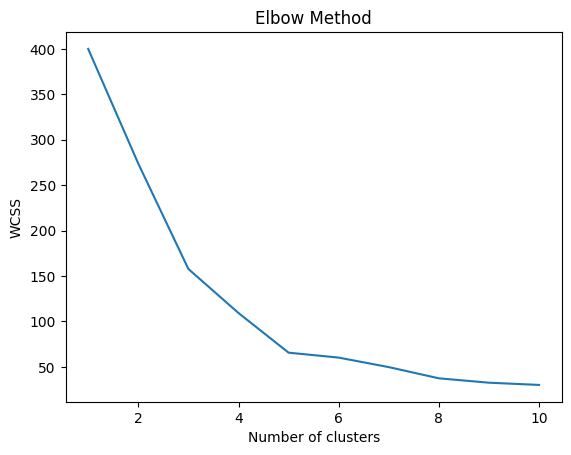

In [14]:
# Plotting the wcss
plt.plot(range(1,11),wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show() # the point at which the curve is bent more, is the K value.

In [16]:
# Defining and training the model once again
kmeans=KMeans(n_clusters=5,random_state=42)
labels=kmeans.fit_predict(X_scaled) #Now that you know the no. of clusters, you will use fit_predict


In [17]:
# Adding cluster named column containing the labels
df['Clusters']=labels

In [18]:
df.head() # Cust0,Cust2,Cust4 have similar spending behavior in terms of annual income

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


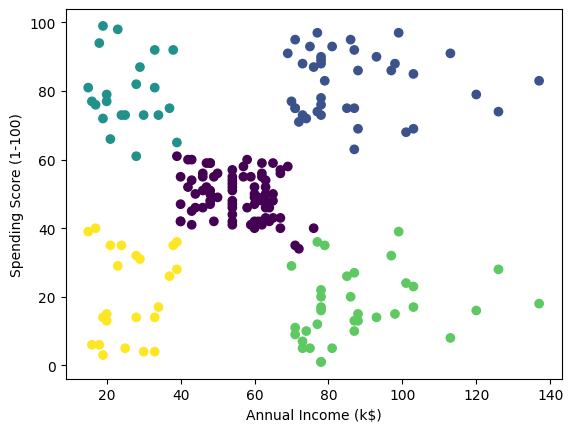

In [19]:
# Visualizing the cluster
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=df['Clusters'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()